In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns
import fastf1 as f1
from fastf1 import plotting
import mplcursors
from ing_theme_matplotlib import mpl_style
import mplcyberpunk

In [2]:
def convert_to_normal(time):
    if pd.isna(time):
        return time

    time_str = str(time)
    parts = time_str.split()

    days = int(parts[0])
    minutes, seconds_with_microseconds = parts[2].split(":")[1:]
    seconds, microseconds = seconds_with_microseconds.split(".")

    minutes = int(minutes)
    seconds = int(seconds)
    microseconds = int(microseconds)

    total_microseconds = (
        days * 86400000000 + minutes * 60000000 + seconds * 1000000 + microseconds
    )

    minutes, remaining_microseconds = divmod(total_microseconds, 60000000)
    seconds, microseconds = divmod(remaining_microseconds, 1000000)

    normal_time = f"{minutes:02d}:{seconds:02d}.{microseconds:06d}"
    return normal_time

## Sprint squali

In [5]:
squali = f1.get_session(2026, "China", "Sprint Qualifying")
squali.load()

core           INFO 	Loading data for Chinese Grand Prix - Sprint Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
core        WARNING 	Sprint Qualifying is not supported by Ergast! Limited results are calculated from timing data.
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 11
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 11)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core         

In [6]:
squali.results.loc[
    :, ["Abbreviation", "TeamName", "GridPosition", "Position", "Time", "Status"]
]

,Abbreviation,TeamName,GridPosition,Position,Time,Status
63,RUS,Mercedes,NaN,1.0,NaT,
12,ANT,Mercedes,NaN,2.0,NaT,
1,NOR,McLaren,NaN,3.0,NaT,
44,HAM,Ferrari,NaN,4.0,NaT,
81,PIA,McLaren,NaN,5.0,NaT,
16,LEC,Ferrari,NaN,6.0,NaT,
10,GAS,Alpine,NaN,7.0,NaT,
3,VER,Red Bull Racing,NaN,8.0,NaT,
87,BEA,Haas F1 Team,NaN,9.0,NaT,
6,HAD,Red Bull Racing,NaN,10.0,NaT,


In [ ]:
squali_laps = squali.laps
squali_laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:18:20.726000,RUS,63,NaT,1.0,1.0,0 days 00:16:26.869000,NaT,NaT,0 days 00:00:30.974000,...,True,Mercedes,0 days 00:16:26.869000,2026-03-13 07:33:46.000,1,NaN,False,,False,False
1,0 days 00:19:53.756000,RUS,63,0 days 00:01:33.030000,2.0,1.0,NaT,NaT,0 days 00:00:24.276000,0 days 00:00:28.182000,...,True,Mercedes,0 days 00:18:20.726000,2026-03-13 07:35:39.857,1,NaN,False,,False,True
2,0 days 00:21:59.292000,RUS,63,0 days 00:02:05.536000,3.0,1.0,NaT,0 days 00:21:57.427000,0 days 00:00:30.753000,0 days 00:00:37.442000,...,True,Mercedes,0 days 00:19:53.756000,2026-03-13 07:37:12.887,1,NaN,False,,False,False
3,0 days 00:36:04.934000,RUS,63,NaT,4.0,2.0,0 days 00:34:05.072000,NaT,NaT,0 days 00:00:36.881000,...,True,Mercedes,0 days 00:21:59.292000,2026-03-13 07:39:18.423,12,NaN,False,,False,False
4,0 days 00:37:37.175000,RUS,63,0 days 00:01:32.241000,5.0,2.0,NaT,NaT,0 days 00:00:24.062000,0 days 00:00:27.790000,...,True,Mercedes,0 days 00:36:04.934000,2026-03-13 07:53:24.065,1,NaN,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,0 days 00:36:24.642000,LIN,41,0 days 00:01:34.048000,9.0,2.0,NaT,NaT,0 days 00:00:24.740000,0 days 00:00:28.531000,...,True,Racing Bulls,0 days 00:34:50.594000,2026-03-13 07:52:09.725,1,NaN,False,,False,True
253,0 days 00:38:25.469000,LIN,41,0 days 00:02:00.827000,10.0,2.0,NaT,NaT,0 days 00:00:31.533000,0 days 00:00:35.920000,...,True,Racing Bulls,0 days 00:36:24.642000,2026-03-13 07:53:43.773,1,NaN,False,,False,True
254,0 days 00:40:18.546000,LIN,41,0 days 00:01:53.077000,11.0,2.0,NaT,NaT,0 days 00:00:28.780000,0 days 00:00:32.230000,...,True,Racing Bulls,0 days 00:38:25.469000,2026-03-13 07:55:44.600,1,NaN,False,,False,True
255,0 days 00:41:52.920000,LIN,41,0 days 00:01:34.374000,12.0,2.0,NaT,NaT,0 days 00:00:24.816000,0 days 00:00:28.508000,...,True,Racing Bulls,0 days 00:40:18.546000,2026-03-13 07:57:37.677,1,NaN,False,,False,True


In [8]:
rus_squali_laps = squali.laps.pick_driver("RUS")
rus_squali = rus_squali_laps.pick_fastest().LapTime
rus_squali_lap_time = rus_squali_laps["LapTime"]
rus_squali_sec1 = rus_squali_laps["Sector1Time"]
rus_squali_sec2 = rus_squali_laps["Sector2Time"]
rus_squali_sec3 = rus_squali_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(rus_squali), "which was in Lap number" ,rus_squali_laps.pick_fastest().LapNumber)
rus_squali_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:31.520000 which was in Lap number 10.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
0,NaT,NaT,0 days 00:00:30.974000,0 days 00:00:54.663000,247.0,245.0,277.0,260.0
1,0 days 00:01:33.030000,0 days 00:00:24.276000,0 days 00:00:28.182000,0 days 00:00:40.572000,276.0,264.0,259.0,318.0
2,0 days 00:02:05.536000,0 days 00:00:30.753000,0 days 00:00:37.442000,0 days 00:00:57.341000,251.0,158.0,NaN,303.0
3,NaT,NaT,0 days 00:00:36.881000,0 days 00:00:53.641000,235.0,50.0,280.0,260.0
4,0 days 00:01:32.241000,0 days 00:00:24.062000,0 days 00:00:27.790000,0 days 00:00:40.389000,275.0,265.0,255.0,320.0


In [9]:
fastest_lap_rus_squali = rus_squali_laps.pick_fastest()
tele_rus_squali = fastest_lap_rus_squali.get_telemetry().add_distance()
speed_rus_squali = tele_rus_squali.Speed
tele_rus_squali.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,289.296877,7,10987.000000
3,290.000000,7,10987.000000
4,291.675002,7,11163.293918
5,294.000000,7,11408.000000
6,299.000000,7,11135.000000
...,...,...,...
701,259.980556,6,10098.113941
702,260.000000,7,10100.000000
703,263.216670,7,10136.187536
704,264.000000,7,10145.000000


In [10]:
nor_squali_laps = squali.laps.pick_driver("NOR")
nor_squali = nor_squali_laps.pick_fastest().LapTime
nor_squali_lap_time = nor_squali_laps["LapTime"]
nor_squali_sec1 = nor_squali_laps["Sector1Time"]
nor_squali_sec2 = nor_squali_laps["Sector2Time"]
nor_squali_sec3 = nor_squali_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(nor_squali), "which was in Lap number" ,nor_squali_laps.pick_fastest().LapNumber)
nor_squali_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:32.141000 which was in Lap number 12.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
26,NaT,NaT,0 days 00:00:31.498000,0 days 00:00:45.987000,252.0,265.0,257.0,288.0
27,0 days 00:01:53.772000,0 days 00:00:26.331000,0 days 00:00:31.920000,0 days 00:00:55.521000,273.0,234.0,275.0,95.0
28,0 days 00:01:33.783000,0 days 00:00:24.587000,0 days 00:00:28.412000,0 days 00:00:40.784000,289.0,275.0,259.0,313.0
29,0 days 00:02:01.769000,0 days 00:00:32.938000,0 days 00:00:33.596000,0 days 00:00:55.235000,234.0,244.0,NaN,256.0
30,NaT,NaT,0 days 00:00:31.260000,0 days 00:00:46.413000,265.0,262.0,256.0,289.0


In [11]:
fastest_lap_nor_squali = nor_squali_laps.pick_fastest()
tele_nor_squali = fastest_lap_nor_squali.get_telemetry().add_distance()
speed_nor_squali = tele_nor_squali.Speed
tele_nor_squali.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,284.191670,7,10979.166144
3,286.000000,7,10726.000000
4,286.000000,7,10726.000000
5,286.000000,8,10726.000000
6,288.785717,8,10726.000000
...,...,...,...
691,254.000000,7,10804.549969
692,254.000000,7,10807.000000
693,258.000000,7,10807.000000
694,259.425000,7,10863.524983


In [12]:
ham_squali_laps = squali.laps.pick_driver("HAM")
ham_squali = ham_squali_laps.pick_fastest().LapTime
ham_squali_lap_time = ham_squali_laps["LapTime"]
ham_squali_sec1 = ham_squali_laps["Sector1Time"]
ham_squali_sec2 = ham_squali_laps["Sector2Time"]
ham_squali_sec3 = ham_squali_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(ham_squali), "which was in Lap number" ,ham_squali_laps.pick_fastest().LapNumber)
ham_squali_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:32.161000 which was in Lap number 12.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
68,NaT,NaT,0 days 00:00:31.395000,0 days 00:00:53.024000,260.0,261.0,276.0,252.0
69,0 days 00:01:33.730000,0 days 00:00:24.740000,0 days 00:00:28.122000,0 days 00:00:40.868000,271.0,273.0,263.0,314.0
70,0 days 00:02:13.715000,0 days 00:00:35.236000,0 days 00:00:44.230000,0 days 00:00:54.249000,206.0,178.0,275.0,263.0
71,0 days 00:01:33.148000,0 days 00:00:24.684000,0 days 00:00:28.061000,0 days 00:00:40.403000,272.0,277.0,256.0,318.0
72,0 days 00:02:12.457000,0 days 00:00:33.072000,0 days 00:00:42.259000,0 days 00:00:57.126000,224.0,251.0,NaN,260.0


In [13]:
fastest_lap_ham_squali = ham_squali_laps.pick_fastest()
tele_ham_squali = fastest_lap_ham_squali.get_telemetry().add_distance()
speed_ham_squali = tele_ham_squali.Speed
tele_ham_squali.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,164.000000,4,10398.000000
3,164.000000,4,10398.000000
4,164.000000,4,10398.000000
5,164.000000,4,10398.000000
6,164.000000,4,10398.000000
...,...,...,...
710,264.059999,6,11391.080041
711,265.000000,6,11361.000000
712,266.129999,6,11148.277620
713,269.000000,7,10608.000000


In [15]:
driver1_sectors = pd.DataFrame(
    {
         "Driver": ["George Russell"] * len(rus_squali_sec1),
        "Sector1Time": rus_squali_sec1,
        "Sector2Time": rus_squali_sec2,
        "Sector3Time": rus_squali_sec3,
        "Lap Time": rus_squali_lap_time,
    }
)


driver2_sectors = pd.DataFrame(
    {
         "Driver": ["Lando Norris"] * len(nor_squali_sec1),
        "Sector1Time": nor_squali_sec1,
        "Sector2Time": nor_squali_sec2,
        "Sector3Time": nor_squali_sec3,
        "Lap Time": nor_squali_lap_time,
    }
)


driver3_sectors = pd.DataFrame(
    {
         "Driver": ["Lewis Hamilton"] * len(ham_squali_sec1),
        "Sector1Time": ham_squali_sec1,
        "Sector2Time": ham_squali_sec2,
        "Sector3Time": ham_squali_sec3,
        "Lap Time": ham_squali_lap_time,
    }
)



all_drivers_sectors = pd.concat(
    [driver1_sectors, driver2_sectors, driver3_sectors],
    ignore_index=True,
)
all_drivers_sectors.sort_values(
    by=["Sector1Time", "Sector2Time", "Sector3Time"], ascending=True
)
all_drivers_sectors.dropna()

,Driver,Sector1Time,Sector2Time,Sector3Time,Lap Time
1,George Russell,0 days 00:00:24.276000,0 days 00:00:28.182000,0 days 00:00:40.572000,0 days 00:01:33.030000
2,George Russell,0 days 00:00:30.753000,0 days 00:00:37.442000,0 days 00:00:57.341000,0 days 00:02:05.536000
4,George Russell,0 days 00:00:24.062000,0 days 00:00:27.790000,0 days 00:00:40.389000,0 days 00:01:32.241000
5,George Russell,0 days 00:00:33.777000,0 days 00:00:42.586000,0 days 00:00:59.481000,0 days 00:02:15.844000
6,George Russell,0 days 00:00:24.226000,0 days 00:00:27.831000,0 days 00:00:40.236000,0 days 00:01:32.293000
7,George Russell,0 days 00:00:29.640000,0 days 00:00:33.981000,0 days 00:00:55.704000,0 days 00:01:59.325000
9,George Russell,0 days 00:00:23.962000,0 days 00:00:27.569000,0 days 00:00:39.989000,0 days 00:01:31.520000
10,George Russell,0 days 00:00:33.731000,0 days 00:00:41.687000,0 days 00:00:48.204000,0 days 00:02:03.622000
11,George Russell,0 days 00:00:23.974000,0 days 00:00:27.627000,0 days 00:00:40.106000,0 days 00:01:31.707000
12,George Russell,0 days 00:00:31.386000,0 days 00:00:36.132000,0 days 00:01:03.864000,0 days 00:02:11.382000


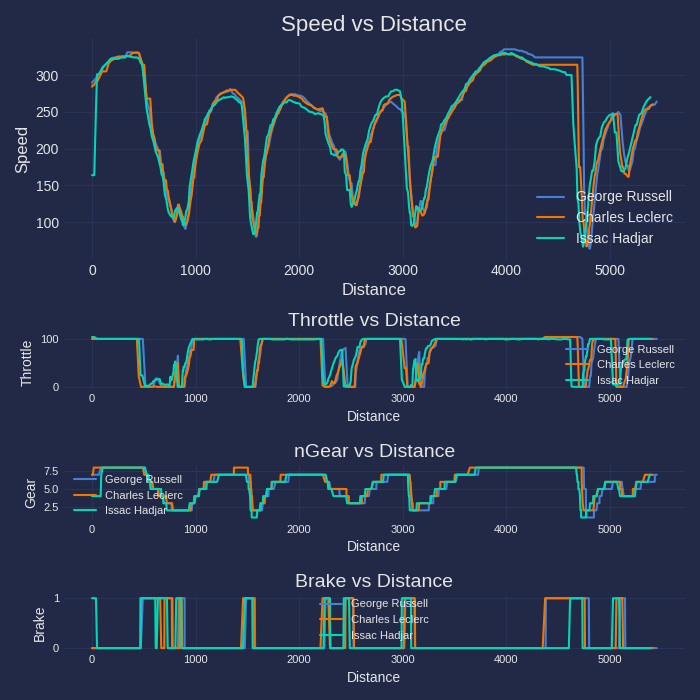

In [18]:
%matplotlib widget

def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i : i + 2], 16) for i in (0, 2, 4)]
    return (r / 255, g / 255, b / 255)


def get_driver_color(driver_abbreviation):
    driver = squali.get_driver(driver_abbreviation)
    team_color = driver.TeamColor
    return hex_to_rgb(team_color)


plt.style.use("cyberpunk")

fig, ax = plt.subplots(4, 1, figsize=(7, 7), gridspec_kw={"height_ratios": [4, 1, 1, 1]})

ax[0].plot(
    tele_rus_squali.Distance, tele_rus_squali.Speed, label="George Russell", color=get_driver_color("VER")
)
ax[0].plot(
    tele_nor_squali.Distance, tele_nor_squali.Speed, label="Charles Leclerc", color=get_driver_color("NOR")
)
ax[0].plot(
    tele_ham_squali.Distance, tele_ham_squali.Speed, label="Issac Hadjar", color=get_driver_color("ANT")
)

ax[0].set_title("Speed vs Distance", fontsize=16)
ax[0].set_xlabel("Distance", fontsize=12)
ax[0].set_ylabel("Speed", fontsize=12)
ax[0].legend(fontsize=10)
ax[0].grid(True)
ax[0].tick_params(axis="both", which="major", labelsize=10)
ax[1].plot(
    tele_rus_squali.Distance, tele_rus_squali.Throttle, label="George Russell", color=get_driver_color("VER")
)
ax[1].plot(
    tele_nor_squali.Distance, tele_nor_squali.Throttle, label="Charles Leclerc", color=get_driver_color("NOR")
)
ax[1].plot(
    tele_ham_squali.Distance, tele_ham_squali.Throttle, label="Issac Hadjar", color=get_driver_color("ANT")
)


ax[1].set_title("Throttle vs Distance", fontsize=14)
ax[1].set_xlabel("Distance", fontsize=10)
ax[1].set_ylabel("Throttle", fontsize=10)
ax[1].legend(fontsize=8)
ax[1].grid(True)
ax[1].tick_params(axis="both", which="major", labelsize=8)
ax[2].plot(
    tele_rus_squali.Distance, tele_rus_squali.nGear, label="George Russell", color=get_driver_color("VER")
)
ax[2].plot(
    tele_nor_squali.Distance, tele_nor_squali.nGear, label="Charles Leclerc", color=get_driver_color("NOR")
)
ax[2].plot(
    tele_ham_squali.Distance, tele_ham_squali.nGear, label="Issac Hadjar", color=get_driver_color("ANT")
)


ax[2].set_title("nGear vs Distance", fontsize=14)
ax[2].set_xlabel("Distance", fontsize=10)
ax[2].set_ylabel("Gear", fontsize=10)
ax[2].legend(fontsize=8)
ax[2].grid(True)
ax[2].tick_params(axis="both", which="major", labelsize=8)
ax[3].plot(
    tele_rus_squali.Distance, tele_rus_squali.Brake, label="George Russell", color=get_driver_color("VER")
)
ax[3].plot(
    tele_nor_squali.Distance, tele_nor_squali.Brake, label="Charles Leclerc", color=get_driver_color("NOR")
)
ax[3].plot(
    tele_ham_squali.Distance, tele_ham_squali.Brake, label="Issac Hadjar", color=get_driver_color("ANT")
)

ax[3].set_title("Brake vs Distance", fontsize=14)
ax[3].set_xlabel("Distance", fontsize=10)
ax[3].set_ylabel("Brake", fontsize=10)
ax[3].legend(fontsize=8)
ax[3].grid(True)
ax[3].tick_params(axis="both", which="major", labelsize=8)

for axis in ax:
    mplcursors.cursor(axis.lines, hover=True)

plt.tight_layout()
plt.show()


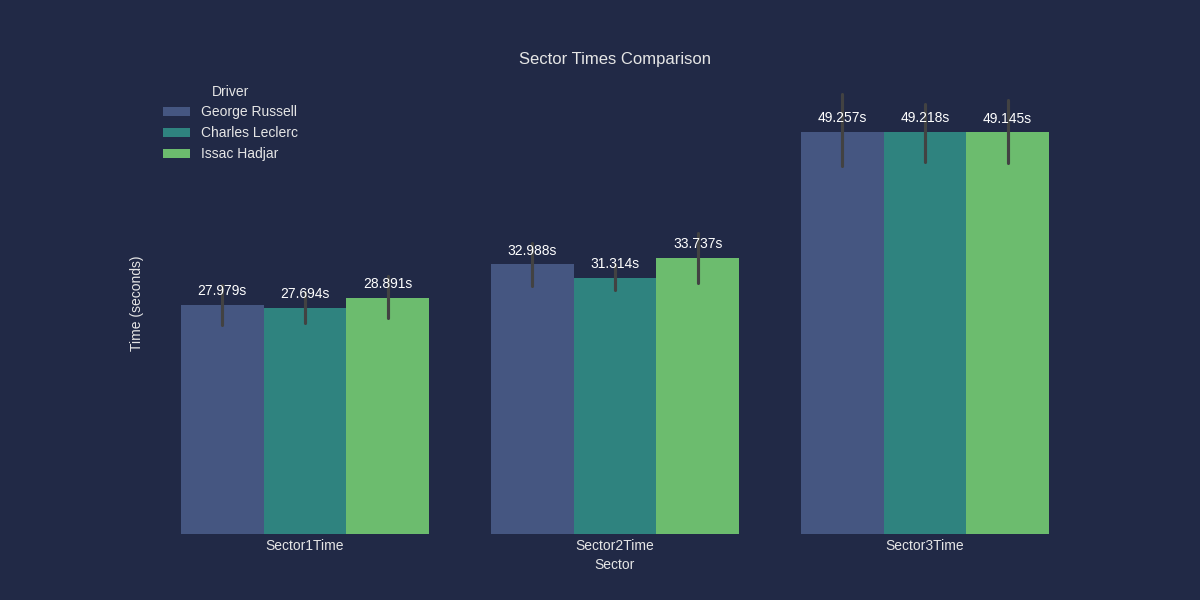

In [20]:
melted_data = all_drivers_sectors.melt(
    id_vars=["Driver"],
    value_vars=["Sector1Time", "Sector2Time", "Sector3Time"],
    var_name="Sector",
    value_name="Time",
)

melted_data["Time"] = melted_data["Time"].dt.total_seconds()

plt.figure(figsize=(12, 6))

bar_plot = sns.barplot(
    data=melted_data, x="Sector", y="Time", hue="Driver", palette="viridis"
)

for p in bar_plot.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        bar_plot.annotate(
            f"{height:.3f}s",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
        va="bottom",
            fontsize=10,
            color="white",
            xytext=(0, 5),
            textcoords="offset points",
        )

plt.title("Sector Times Comparison")
plt.ylabel("Time (seconds)")
plt.xlabel("Sector")
plt.gca().set_yticks([])
plt.show()

## Sprint Race

In [22]:
sprint = f1.get_session(2026, "China", "Sprint")
sprint.load()

core           INFO 	Loading data for Chinese Grand Prix - Sprint [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No 

In [23]:
sprint.session_info

{'Meeting': {'Key': 1280,
  'Name': 'Chinese Grand Prix',
  'OfficialName': 'FORMULA 1 HEINEKEN CHINESE GRAND PRIX 2026',
  'Location': 'Shanghai',
  'Number': 2,
  'Country': {'Key': 53, 'Code': 'CHN', 'Name': 'China'},
  'Circuit': {'Key': 49, 'ShortName': 'Shanghai'}},
 'SessionStatus': 'Inactive',
 'ArchiveStatus': {'Status': 'Generating'},
 'Key': 11240,
 'Type': 'Race',
 'Name': 'Sprint',
 'StartDate': datetime.datetime(2026, 3, 14, 11, 0),
 'EndDate': datetime.datetime(2026, 3, 14, 12, 0),
 'GmtOffset': datetime.timedelta(seconds=28800),
 'Path': '2026/2026-03-15_Chinese_Grand_Prix/2026-03-14_Sprint/'}

In [24]:
sprint.results.loc[
    :, ["Abbreviation", "TeamName", "GridPosition", "Position", "Time", "Status"]
]

,Abbreviation,TeamName,GridPosition,Position,Time,Status
63,RUS,Mercedes,1.0,1.0,0 days 00:33:38.998000,Finished
16,LEC,Ferrari,6.0,2.0,0 days 00:00:00.674000,Finished
44,HAM,Ferrari,4.0,3.0,0 days 00:00:02.554000,Finished
1,NOR,McLaren,3.0,4.0,0 days 00:00:04.433000,Finished
12,ANT,Mercedes,2.0,5.0,0 days 00:00:05.688000,Finished
81,PIA,McLaren,5.0,6.0,0 days 00:00:06.809000,Finished
30,LAW,Racing Bulls,13.0,7.0,0 days 00:00:10.900000,Finished
87,BEA,Haas F1 Team,9.0,8.0,0 days 00:00:11.271000,Finished
3,VER,Red Bull Racing,8.0,9.0,0 days 00:00:11.619000,Finished
31,OCO,Haas F1 Team,12.0,10.0,0 days 00:00:13.887000,Finished


In [25]:
sprint_laps = sprint.laps
sprint_laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:48:24.706000,NOR,1,NaT,1.0,1.0,NaT,NaT,NaT,0 days 00:00:31.201000,...,False,McLaren,0 days 00:46:41.459000,2026-03-14 03:03:53.833,12,4.0,False,,False,False
1,0 days 00:50:02.796000,NOR,1,0 days 00:01:38.090000,2.0,1.0,NaT,NaT,0 days 00:00:25.842000,0 days 00:00:29.806000,...,False,McLaren,0 days 00:48:24.706000,2026-03-14 03:05:37.080,1,4.0,False,,False,True
2,0 days 00:51:40.743000,NOR,1,0 days 00:01:37.947000,3.0,1.0,NaT,NaT,0 days 00:00:25.835000,0 days 00:00:29.630000,...,False,McLaren,0 days 00:50:02.796000,2026-03-14 03:07:15.170,1,4.0,False,,False,True
3,0 days 00:53:18.765000,NOR,1,0 days 00:01:38.022000,4.0,1.0,NaT,NaT,0 days 00:00:25.829000,0 days 00:00:29.566000,...,False,McLaren,0 days 00:51:40.743000,2026-03-14 03:08:53.117,1,4.0,False,,False,True
4,0 days 00:54:56.285000,NOR,1,0 days 00:01:37.520000,5.0,1.0,NaT,NaT,0 days 00:00:25.663000,0 days 00:00:29.547000,...,False,McLaren,0 days 00:53:18.765000,2026-03-14 03:10:31.139,1,4.0,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,0 days 01:13:17.867000,BEA,87,0 days 00:02:27.072000,15.0,1.0,NaT,NaT,0 days 00:00:38.524000,0 days 00:00:43.918000,...,False,Haas F1 Team,0 days 01:10:50.795000,2026-03-14 03:28:03.169,4,6.0,False,,False,False
393,0 days 01:15:37.584000,BEA,87,0 days 00:02:19.717000,16.0,1.0,NaT,NaT,0 days 00:00:37.257000,0 days 00:00:41.298000,...,False,Haas F1 Team,0 days 01:13:17.867000,2026-03-14 03:30:30.241,41,6.0,False,,False,False
394,0 days 01:17:16.973000,BEA,87,0 days 00:01:39.389000,17.0,1.0,NaT,NaT,0 days 00:00:25.733000,0 days 00:00:30.414000,...,False,Haas F1 Team,0 days 01:15:37.584000,2026-03-14 03:32:49.958,1,8.0,False,,False,True
395,0 days 01:18:54.347000,BEA,87,0 days 00:01:37.374000,18.0,1.0,NaT,NaT,0 days 00:00:25.378000,0 days 00:00:29.567000,...,False,Haas F1 Team,0 days 01:17:16.973000,2026-03-14 03:34:29.347,1,8.0,False,,False,True


In [26]:
rus_sprint_laps = sprint.laps.pick_driver("RUS")
fastest_lap_rus_sprint = rus_sprint_laps.pick_fastest().LapTime
rus_sprint_lap_time = rus_sprint_laps["LapTime"]
rus_sprint_sec1 = rus_sprint_laps["Sector1Time"]
rus_sprint_sec2 = rus_sprint_laps["Sector2Time"]
rus_sprint_sec3 = rus_sprint_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_rus_sprint), "which was in Lap number" ,rus_sprint_laps.pick_fastest().LapNumber)
rus_sprint_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:35.101000 which was in Lap number 18.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
328,NaT,NaT,0 days 00:00:30.512000,0 days 00:00:42.404000,284.0,268.0,271.0,314.0
329,0 days 00:01:38.258000,0 days 00:00:26.292000,0 days 00:00:29.399000,0 days 00:00:42.567000,281.0,267.0,270.0,313.0
330,0 days 00:01:36.852000,0 days 00:00:25.875000,0 days 00:00:29.381000,0 days 00:00:41.596000,283.0,267.0,268.0,317.0
331,0 days 00:01:38.518000,0 days 00:00:26.188000,0 days 00:00:30.034000,0 days 00:00:42.296000,286.0,266.0,278.0,307.0
332,0 days 00:01:36.899000,0 days 00:00:25.469000,0 days 00:00:29.381000,0 days 00:00:42.049000,286.0,273.0,268.0,319.0


In [27]:
fastest_lap_rus_sprint = rus_sprint_laps.pick_fastest()
tele_rus_sprint = fastest_lap_rus_sprint.get_telemetry().add_distance()
speed_rus_sprint = tele_rus_sprint.Speed
tele_rus_sprint.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,152.000000,4,8935.000000
3,152.000000,4,8935.000000
4,152.000000,4,8935.000000
5,152.000000,4,8935.000000
6,152.000000,4,8935.000000
...,...,...,...
693,270.000000,7,10703.000000
694,270.000000,7,10703.000000
695,270.000000,7,10703.000000
696,270.000000,7,10703.000000


In [28]:
lec_sprint_laps = sprint.laps.pick_driver("LEC")
fastest_lap_lec_sprint = lec_sprint_laps.pick_fastest().LapTime
lec_sprint_lap_time = lec_sprint_laps["LapTime"]
lec_sprint_sec1 = lec_sprint_laps["Sector1Time"]
lec_sprint_sec2 = lec_sprint_laps["Sector2Time"]
lec_sprint_sec3 = lec_sprint_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_lec_sprint), "which was in Lap number" ,lec_sprint_laps.pick_fastest().LapNumber)
lec_sprint_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:34.753000 which was in Lap number 18.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
95,NaT,NaT,0 days 00:00:29.905000,0 days 00:00:42.750000,289.0,263.0,278.0,305.0
96,0 days 00:01:37.665000,0 days 00:00:26.088000,0 days 00:00:29.358000,0 days 00:00:42.219000,276.0,267.0,275.0,311.0
97,0 days 00:01:37.536000,0 days 00:00:26.158000,0 days 00:00:29.288000,0 days 00:00:42.090000,273.0,270.0,278.0,315.0
98,0 days 00:01:38.072000,0 days 00:00:25.732000,0 days 00:00:29.807000,0 days 00:00:42.533000,277.0,266.0,275.0,318.0
99,0 days 00:01:37.029000,0 days 00:00:25.598000,0 days 00:00:29.170000,0 days 00:00:42.261000,280.0,270.0,278.0,316.0


In [29]:
fastest_lap_lec_sprint = lec_sprint_laps.pick_fastest()
tele_lec_sprint = fastest_lap_lec_sprint.get_telemetry().add_distance()
speed_lec_sprint = tele_lec_sprint.Speed
tele_lec_sprint.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,283.811387,7,11273.384324
3,286.900356,7,11346.637010
4,287.000000,7,11349.000000
5,289.700000,7,11451.600000
6,291.000000,7,11501.000000
...,...,...,...
692,257.766667,6,11617.500000
693,258.000000,6,11614.000000
694,264.300000,6,10735.600000
695,265.000000,6,10638.000000


In [30]:
nor_sprint_laps = sprint.laps.pick_driver("NOR")
fastest_lap_nor_sprint = nor_sprint_laps.pick_fastest().LapTime
nor_sprint_lap_time = nor_sprint_laps["LapTime"]
nor_sprint_sec1 = nor_sprint_laps["Sector1Time"]
nor_sprint_sec2 = nor_sprint_laps["Sector2Time"]
nor_sprint_sec3 = nor_sprint_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_nor_sprint), "which was in Lap number" ,nor_sprint_laps.pick_fastest().LapNumber)
nor_sprint_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:35.708000 which was in Lap number 19.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
0,NaT,NaT,0 days 00:00:31.201000,0 days 00:00:43.008000,291.0,275.0,274.0,328.0
1,0 days 00:01:38.090000,0 days 00:00:25.842000,0 days 00:00:29.806000,0 days 00:00:42.442000,281.0,269.0,272.0,311.0
2,0 days 00:01:37.947000,0 days 00:00:25.835000,0 days 00:00:29.630000,0 days 00:00:42.482000,280.0,269.0,268.0,308.0
3,0 days 00:01:38.022000,0 days 00:00:25.829000,0 days 00:00:29.566000,0 days 00:00:42.627000,279.0,269.0,271.0,306.0
4,0 days 00:01:37.520000,0 days 00:00:25.663000,0 days 00:00:29.547000,0 days 00:00:42.310000,280.0,268.0,273.0,304.0


In [31]:
fastest_lap_nor_sprint = nor_sprint_laps.pick_fastest()
tele_nor_sprint = fastest_lap_nor_sprint.get_telemetry().add_distance()
speed_nor_sprint = tele_nor_sprint.Speed
tele_nor_sprint.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,271.0,7,11469.0
3,271.0,7,11469.0
4,271.0,7,11469.0
5,271.0,7,11469.0
6,271.0,7,11469.0
...,...,...,...
720,272.0,7,11446.0
721,272.2,7,11446.0
722,274.0,7,11446.0
723,274.0,7,11446.0


In [32]:
driver1_sectors = pd.DataFrame(
    {
         "Driver": ["George Russell"] * len(rus_sprint_sec1),
        "Sector1Time": rus_sprint_sec1,
        "Sector2Time": rus_sprint_sec2,
        "Sector3Time": rus_sprint_sec3,
        "Lap Time": rus_sprint_lap_time,
    }
)

driver2_sectors = pd.DataFrame(
    {
         "Driver": ["Charles Leclerc"] * len(lec_sprint_sec1),
        "Sector1Time": lec_sprint_sec1,
        "Sector2Time": lec_sprint_sec2,
        "Sector3Time": lec_sprint_sec3,
        "Lap Time": lec_sprint_lap_time,
    }
)


driver3_sectors = pd.DataFrame(
    {
         "Driver": ["Lando Norris"] * len(nor_sprint_sec1),
        "Sector1Time": nor_sprint_sec1,
        "Sector2Time": nor_sprint_sec2,
        "Sector3Time": nor_sprint_sec3,
        "Lap Time": nor_sprint_lap_time,
    }
)


all_drivers_sectors = pd.concat(
    [driver1_sectors, driver2_sectors, driver3_sectors],
    ignore_index=True,
)
all_drivers_sectors.sort_values(
    by=["Sector1Time", "Sector2Time", "Sector3Time"], ascending=True
)
all_drivers_sectors.dropna()

,Driver,Sector1Time,Sector2Time,Sector3Time,Lap Time
1,George Russell,0 days 00:00:26.292000,0 days 00:00:29.399000,0 days 00:00:42.567000,0 days 00:01:38.258000
2,George Russell,0 days 00:00:25.875000,0 days 00:00:29.381000,0 days 00:00:41.596000,0 days 00:01:36.852000
3,George Russell,0 days 00:00:26.188000,0 days 00:00:30.034000,0 days 00:00:42.296000,0 days 00:01:38.518000
4,George Russell,0 days 00:00:25.469000,0 days 00:00:29.381000,0 days 00:00:42.049000,0 days 00:01:36.899000
5,George Russell,0 days 00:00:25.577000,0 days 00:00:29.017000,0 days 00:00:42.121000,0 days 00:01:36.715000
6,George Russell,0 days 00:00:25.780000,0 days 00:00:29.037000,0 days 00:00:42.097000,0 days 00:01:36.914000
7,George Russell,0 days 00:00:25.628000,0 days 00:00:29.116000,0 days 00:00:42.216000,0 days 00:01:36.960000
8,George Russell,0 days 00:00:25.614000,0 days 00:00:29.428000,0 days 00:00:42.050000,0 days 00:01:37.092000
9,George Russell,0 days 00:00:25.612000,0 days 00:00:29.201000,0 days 00:00:41.933000,0 days 00:01:36.746000
10,George Russell,0 days 00:00:25.736000,0 days 00:00:29.247000,0 days 00:00:42.269000,0 days 00:01:37.252000


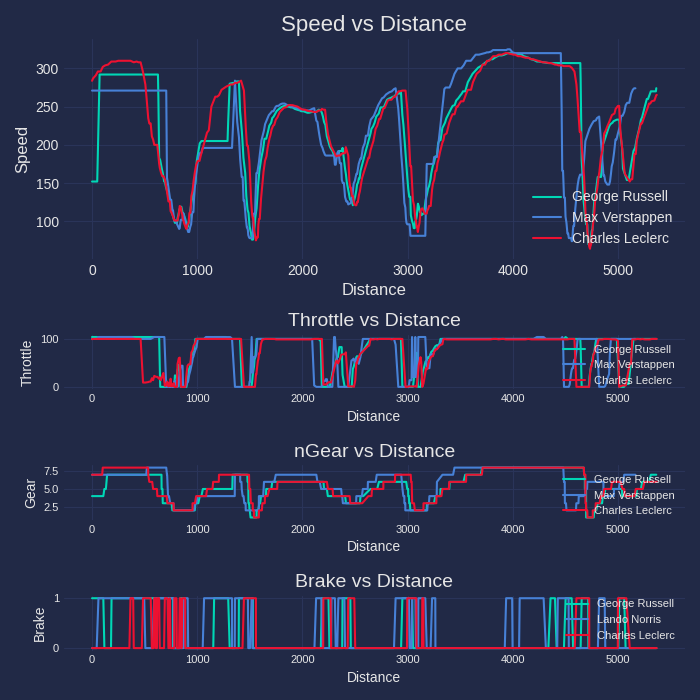

In [34]:
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i : i + 2], 16) for i in (0, 2, 4)]
    return (r / 255, g / 255, b / 255)


def get_driver_color(driver_abbreviation):
    driver = sprint.get_driver(driver_abbreviation)
    team_color = driver.TeamColor
    return hex_to_rgb(team_color)


plt.style.use("cyberpunk")

fig, ax = plt.subplots(4, 1, figsize=(7, 7), gridspec_kw={"height_ratios": [4, 1, 1, 1]})

ax[0].plot(
    tele_rus_sprint.Distance, tele_rus_sprint.Speed, label="George Russell", color=get_driver_color("RUS")
)
ax[0].plot(
    tele_nor_sprint.Distance, tele_nor_sprint.Speed, label="Max Verstappen", color=get_driver_color("VER")
)
ax[0].plot(
    tele_lec_sprint.Distance, tele_lec_sprint.Speed, label="Charles Leclerc", color=get_driver_color("LEC")
)

ax[0].set_title("Speed vs Distance", fontsize=16)
ax[0].set_xlabel("Distance", fontsize=12)
ax[0].set_ylabel("Speed", fontsize=12)
ax[0].legend(fontsize=10)
ax[0].grid(True)
ax[0].tick_params(axis="both", which="major", labelsize=10)

ax[1].plot(
    tele_rus_sprint.Distance, tele_rus_sprint.Throttle, label="George Russell", color=get_driver_color("RUS")
)
ax[1].plot(
    tele_nor_sprint.Distance, tele_nor_sprint.Throttle, label="Max Verstappen", color=get_driver_color("VER")
)
ax[1].plot(
    tele_lec_sprint.Distance, tele_lec_sprint.Throttle, label="Charles Leclerc", color=get_driver_color("LEC")
)

ax[1].set_title("Throttle vs Distance", fontsize=14)
ax[1].set_xlabel("Distance", fontsize=10)
ax[1].set_ylabel("Throttle", fontsize=10)
ax[1].legend(fontsize=8)
ax[1].grid(True)
ax[1].tick_params(axis="both", which="major", labelsize=8)
ax[2].plot(
    tele_rus_sprint.Distance, tele_rus_sprint.nGear, label="George Russell", color=get_driver_color("RUS")
)
ax[2].plot(
    tele_nor_sprint.Distance, tele_nor_sprint.nGear, label="Max Verstappen", color=get_driver_color("VER")
)
ax[2].plot(
    tele_lec_sprint.Distance, tele_lec_sprint.nGear, label="Charles Leclerc", color=get_driver_color("LEC")
)

ax[2].set_title("nGear vs Distance", fontsize=14)
ax[2].set_xlabel("Distance", fontsize=10)
ax[2].set_ylabel("Gear", fontsize=10)
ax[2].legend(fontsize=8)
ax[2].grid(True)
ax[2].tick_params(axis="both", which="major", labelsize=8)
ax[3].plot(
    tele_rus_sprint.Distance, tele_rus_sprint.Brake, label="George Russell", color=get_driver_color("RUS")
)
ax[3].plot(
    tele_nor_sprint.Distance, tele_nor_sprint.Brake, label="Lando Norris", color=get_driver_color("VER")
)
ax[3].plot(
    tele_lec_sprint.Distance, tele_lec_sprint.Brake, label="Charles Leclerc", color=get_driver_color("LEC")
)
ax[3].set_title("Brake vs Distance", fontsize=14)
ax[3].set_xlabel("Distance", fontsize=10)
ax[3].set_ylabel("Brake", fontsize=10)
ax[3].legend(fontsize=8)
ax[3].grid(True)
ax[3].tick_params(axis="both", which="major", labelsize=8)

plt.tight_layout()
plt.show()


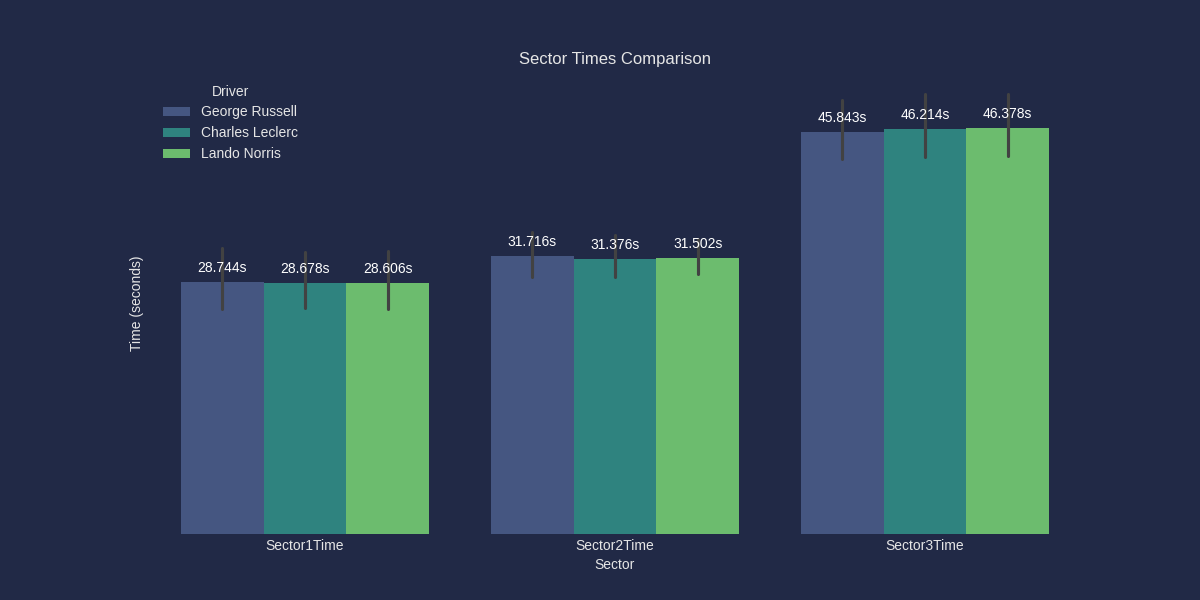

In [35]:
melted_data = all_drivers_sectors.melt(
    id_vars=["Driver"],
    value_vars=["Sector1Time", "Sector2Time", "Sector3Time"],
    var_name="Sector",
    value_name="Time",
)

melted_data["Time"] = melted_data["Time"].dt.total_seconds()

plt.figure(figsize=(12, 6))

bar_plot = sns.barplot(
    data=melted_data, x="Sector", y="Time", hue="Driver", palette="viridis"
)

for p in bar_plot.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        bar_plot.annotate(
            f"{height:.3f}s",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
        va="bottom",
            fontsize=10,
            color="white",
            xytext=(0, 5),
            textcoords="offset points",
        )

plt.title("Sector Times Comparison")
plt.ylabel("Time (seconds)")
plt.xlabel("Sector")
plt.gca().set_yticks([])
plt.show()

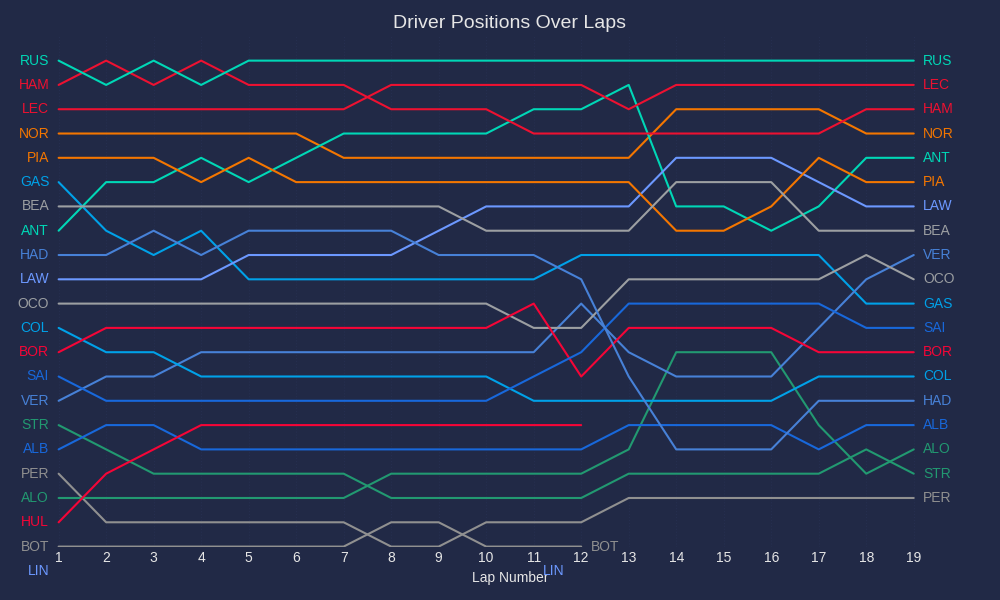

In [36]:
drivers = sprint.laps.Driver.unique()
drivers_ab = drivers.tolist()
nlaps = int(sprint.laps.LapNumber.unique().max())

team_colors = {}

for driver in drivers_ab:
    driver_object = sprint.get_driver(driver)
    hex_color = driver_object.TeamColor
    team_colors[driver] = hex_to_rgb(hex_color)

plt.figure(figsize=(10, 6))
for driver in drivers_ab:
    positions = sprint_laps[sprint_laps['Driver'] == driver]['Position'].values  
    color = team_colors.get(driver, (0.5, 0.5, 0.5))
    plt.plot(range(1, len(positions) + 1), positions, label=driver, color=color)
    
    plt.text(
        1 - 0.2,
        positions[0],
        driver,
        color=color,
        fontsize=10,
        verticalalignment='center',
        horizontalalignment='right'
    )
    
    plt.text(
        len(positions) + 0.2,
        positions[-1],
        driver,
        color=color,
        fontsize=10,
        verticalalignment='center',
        horizontalalignment='left'
    )

plt.title("Driver Positions Over Laps", fontsize=14)
plt.grid(True, linestyle=':', alpha=0.5)
plt.xlim(0.5, float(nlaps) + 1.5)
plt.xlabel("Lap Number")
plt.ylim(0, 21)
plt.gca().invert_yaxis()
plt.gca().set_yticks([])
plt.xticks(range(1, nlaps + 1))
plt.tight_layout()
plt.show()

In [37]:
res = sprint.results
drivers = res['Abbreviation'].tolist()
fastest_speed = pd.DataFrame(columns=['Driver', 'Speed'])
for i in drivers:
    tele = sprint.laps.pick_driver(i)
    speed = tele.SpeedST.max()
    df = pd.DataFrame({'Driver': [i], 'Speed': [speed]})
    fastest_speed = pd.concat([fastest_speed, df], ignore_index=True)
fastest_speed.sort_values(by="Speed",ascending=True)


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/tmp/ipykernel_24352/4231460989.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fastest_speed = pd.concat([fastest_speed, df], ignore_index=True)


,Driver,Speed
21,LIN,310.0
0,RUS,319.0
16,ALO,320.0
18,PER,325.0
5,PIA,326.0
1,LEC,326.0
3,NOR,328.0
7,BEA,329.0
19,HUL,330.0
6,LAW,332.0


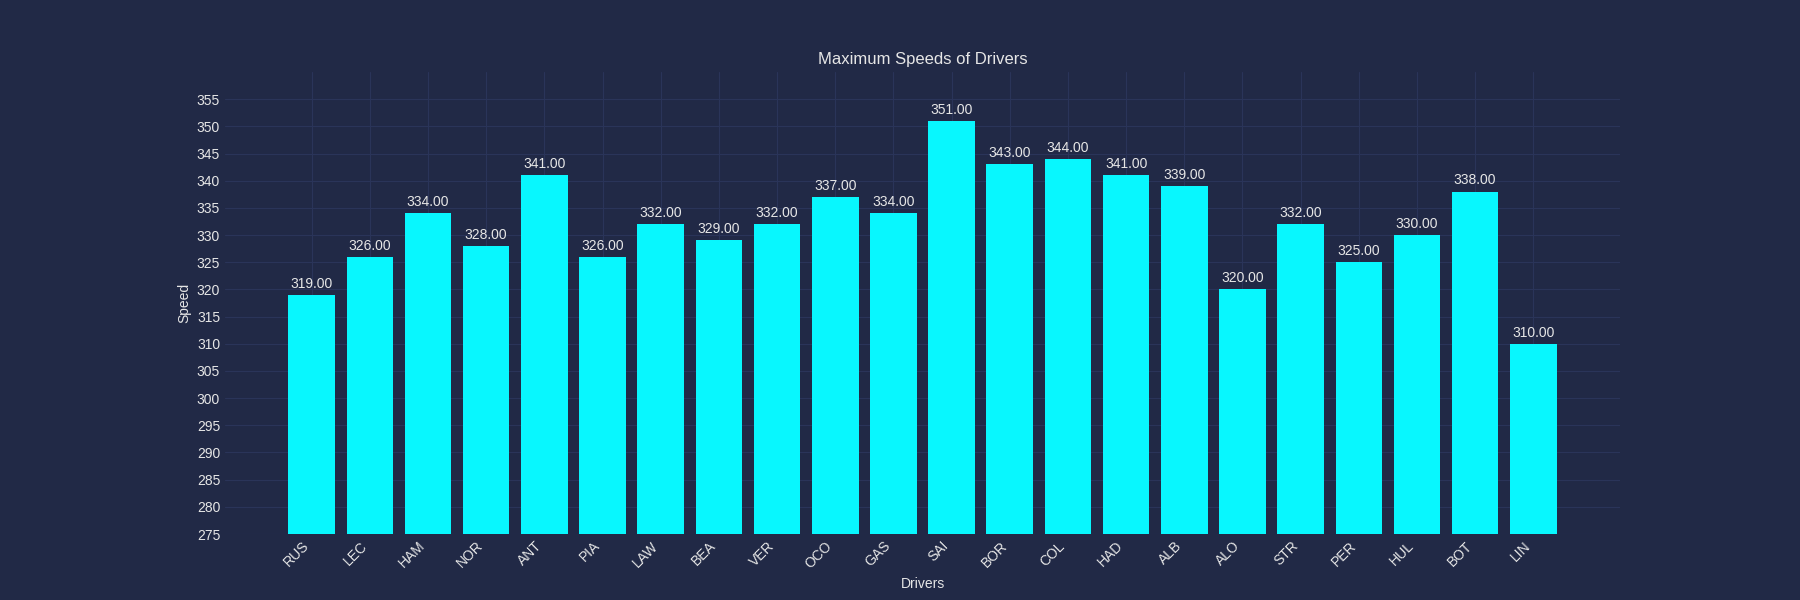

In [38]:
fig,ax = plt.subplots(figsize=(18, 6))
bars = ax.bar(fastest_speed['Driver'], fastest_speed['Speed'])
ax.set_xlabel('Drivers')
ax.set_ylabel('Speed')
ax.set_title('Maximum Speeds of Drivers')
plt.xticks(rotation=45, ha='right')

y_min = 275
y_max = np.ceil(fastest_speed['Speed'].max() / 5) * 5 + 5
y_ticks = np.arange(y_min, y_max, 5)
ax.set_ylim(y_min, y_max)
ax.set_yticks(y_ticks)

for bar in bars:
    height = bar.get_height()
    ax.annotate('{:.2f}'.format(height),
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.show()

In [39]:
plotting.setup_mpl()

In [40]:
laps_rus = sprint_laps.pick_driver("RUS")
laps_lec = sprint_laps.pick_driver("LEC")

fastest_rus = laps_rus.pick_fastest().get_telemetry().add_distance()
fastest_lec = laps_lec.pick_fastest().get_telemetry().add_distance()

fastest_rus["Driver"] = "RUS"
fastest_lec["Driver"] = "LEC"
telemetry = pd.concat([fastest_rus,fastest_lec])

/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


In [41]:
num_minisectors = 25
total_distance = total_distance = max(telemetry['Distance'])
minisector_length = total_distance / num_minisectors
minisectors = [0]
for i in range(0, (num_minisectors - 1)):
    minisectors.append(minisector_length * (i + 1))
telemetry['Minisector'] = telemetry['Distance'].apply(
    lambda dist: (
        int((dist // minisector_length) + 1)
    )
)

In [42]:
average_speed = telemetry.groupby(['Minisector', 'Driver'])['Speed'].mean().reset_index()
average_speed

,Minisector,Driver,Speed
0,1,LEC,298.269332
1,1,RUS,235.920285
2,2,LEC,309.507176
3,2,RUS,292.000000
4,3,LEC,234.095372
5,3,RUS,280.082857
6,4,LEC,121.806805
7,4,RUS,123.464702
8,5,LEC,123.319491
9,5,RUS,132.069604


In [43]:
fastest_driver = average_speed.loc[average_speed.groupby(['Minisector'])['Speed'].idxmax()]

fastest_driver = fastest_driver[['Minisector', 'Driver']].rename(columns={'Driver': 'Fastest_driver'})


In [44]:
telemetry = telemetry.merge(fastest_driver, on=['Minisector'])

telemetry = telemetry.sort_values(by=['Distance'])

telemetry.loc[telemetry['Fastest_driver'] == 'RUS', 'Fastest_driver_int'] = 1
telemetry.loc[telemetry['Fastest_driver'] == 'LEC', 'Fastest_driver_int'] = 2

In [ ]:
x = np.array(telemetry['X'].values)
y = np.array(telemetry['Y'].values)

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
fastest_driver_array = telemetry['Fastest_driver_int'].to_numpy().astype(float)

cmap = plt.get_cmap('winter', 2)  # Create a colormap with 2 colors
lc_comp = LineCollection(segments, norm=plt.Normalize(1, cmap.N+1), cmap=cmap)
lc_comp.set_array(fastest_driver_array)
lc_comp.set_linewidth(5)

plt.rcParams['figure.figsize'] = [18, 10]
plt.gca().add_collection(lc_comp)
plt.axis('equal')
plt.tick_params(labelleft=False, left=False, labelbottom=False, bottom=False)

cbar = plt.colorbar(mappable=lc_comp, boundaries=[1, 2, 3])
cbar.set_ticks([1.5, 2.5])
cbar.set_ticklabels(['RUS', 'LEC'])
plt.title("George Russell vs Charles Leclerc Pace")
plt.show()


## Quali